In [1]:
import pandas as pd

In [2]:
# read original data and feature matrix

In [3]:
x_train = pd.read_csv("x_train.csv")
data =  pd.read_csv("Hotel Reservations.csv")

In [4]:
# reduce the number of rows in data if you face memory issues
# This is just to see end to end execution - not a recommended step

x_train = x_train[0:10000]
data = data[0:10000]

In [5]:
x_train_copy = x_train.copy()

In [6]:
# Try agglomerative clustering with cosine distance metric and distance threshold as input
# You can also specify n_clusters and set distance_threshold to None
# You can try different distance metrics and linkage criterias

In [7]:
from sklearn.cluster import AgglomerativeClustering


clustering = AgglomerativeClustering( n_clusters = None,
                                      linkage = 'complete',
                                      distance_threshold = 0.5, # if n_clusters is number then this should be None
                                      metric = 'cosine')

clustering.fit(x_train)
x_train['cluster_labels'] = clustering.labels_
x_train['booking_status'] = data['booking_status']
print(x_train['cluster_labels'].value_counts())

17    3312
5     1758
7     1476
0     1394
1      500
8      488
4      437
6      238
18     159
9       70
2       27
12      21
21      18
10      17
20      16
13      15
3       13
19      13
11      12
22       7
14       4
15       3
16       2
Name: cluster_labels, dtype: int64


In [8]:
# get cancellation rate in each cluster

In [9]:
cluster_number = []
cancellation_rate = []

for z in range(len(list(x_train['cluster_labels'].unique()))):
               cluster_number.append(z)
               temp = x_train[x_train['cluster_labels']==z]
               temp_cancelled = temp[temp['booking_status']=='Canceled']
               temp_not_cancelled = temp[temp['booking_status']=='Not_Canceled']
               cancel = (len(temp_cancelled)/len(temp))*100
               cancellation_rate.append(cancel)

<AxesSubplot: xlabel='cluster', ylabel='cancellation'>

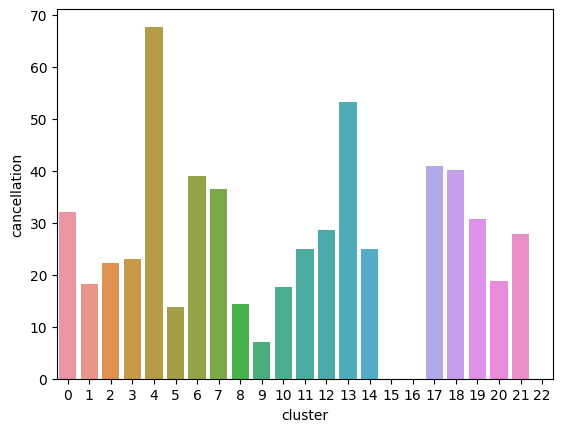

In [10]:
import seaborn as sns
temp = pd.DataFrame({'cluster':cluster_number, 'cancellation': cancellation_rate})
sns.barplot(x = 'cluster',y = 'cancellation', data = temp)

In [11]:
# get silehoutee score

In [12]:
from sklearn.metrics import silhouette_score
silhouette_score(x_train_copy, clustering.labels_)

0.6345863093209952